# Installs

In [1]:
!pip install pandas matplotlib seaborn plotly  fredapi

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from fredapi import Fred
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

In [30]:
fred = Fred(api_key='e956a3dbccd7d4f90be734f8d55b1d07')

series_ids = {
    'RSAFS': 'Retail Sales: All Food Services (Target)',
    'CPIAUCSL': 'Consumer Price Index',
    'UNRATE': 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PCE': 'Personal Consumption Expenditures',
    'DSPIC96': 'Real Disposable Personal Income'
}

data = pd.DataFrame()
for series_id in series_ids:
    data[series_id] = fred.get_series(series_id)

data.index = fred.get_series('RSAFS').index
data.dropna(inplace=True)

data.rename(columns=series_ids, inplace=True)
data.reset_index(inplace=True)
data.rename(columns={'index': 'ds', 'Retail Sales: All Food Services (Target)': 'y'}, inplace=True)

df = data.copy()

# EDA

Basic Info and Descriptive Stats

In [32]:
print("\n--- Data Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   ds                                 399 non-null    datetime64[ns]
 1   y                                  399 non-null    float64       
 2   Consumer Price Index               399 non-null    float64       
 3   Unemployment Rate                  399 non-null    float64       
 4   Federal Funds Rate                 399 non-null    float64       
 5   Personal Consumption Expenditures  399 non-null    float64       
 6   Real Disposable Personal Income    399 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 21.9 KB
None

--- Missing Values ---
ds                                   0
y                                    0
Consumer Price Index                 0
Unemployment Rate               

TIME SERIES PLOTS FOR ALL VARIABLES

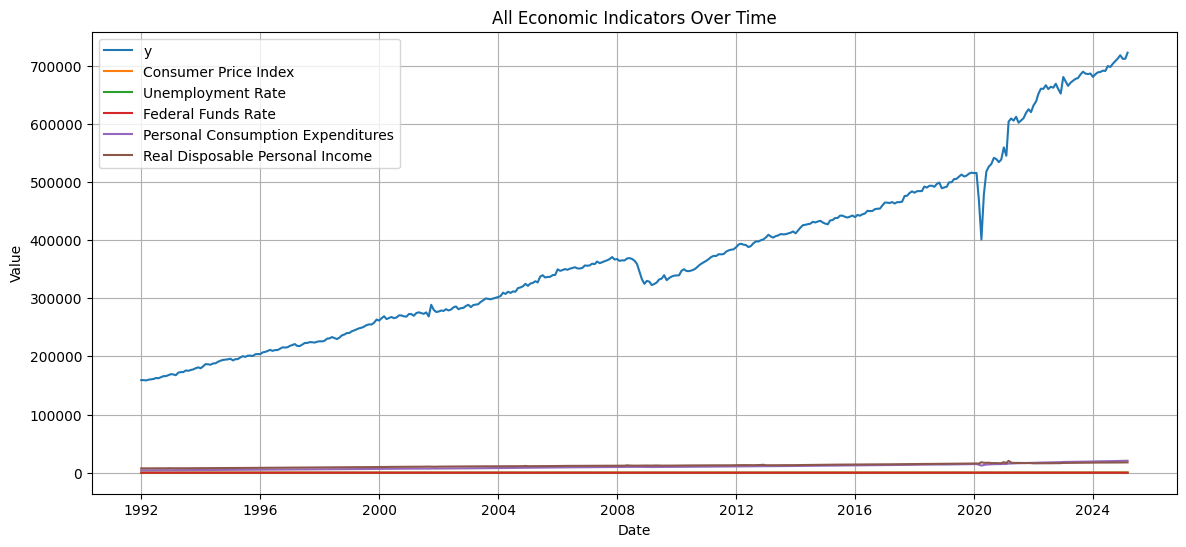

In [33]:
plt.figure(figsize=(14, 6))
for col in df.columns[1:]:
    plt.plot(df['ds'], df[col], label=col)
plt.title("All Economic Indicators Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

UNEMPLOYMENT RATE ANALYSIS

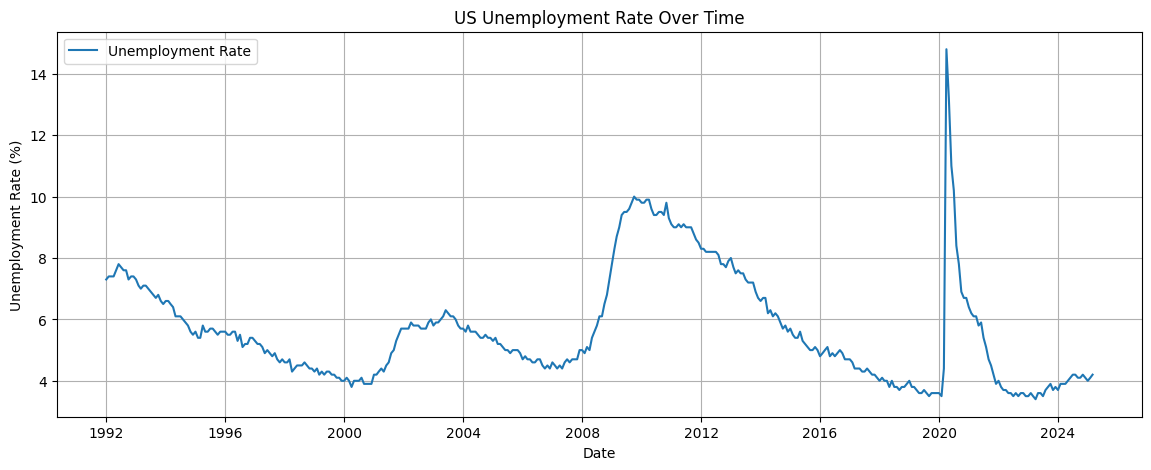

In [34]:
plt.figure(figsize=(14, 5))
plt.plot(df['ds'], df['Unemployment Rate'], label='Unemployment Rate')
plt.title("US Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.legend()
plt.show()

Plot: Unemployment Rate Over Time (interactive)


In [35]:
fig = px.line(df, x='ds', y='Unemployment Rate', title='US Unemployment Rate Over Time (Interactive)')
fig.show()

Distribution of Unemployment Rat

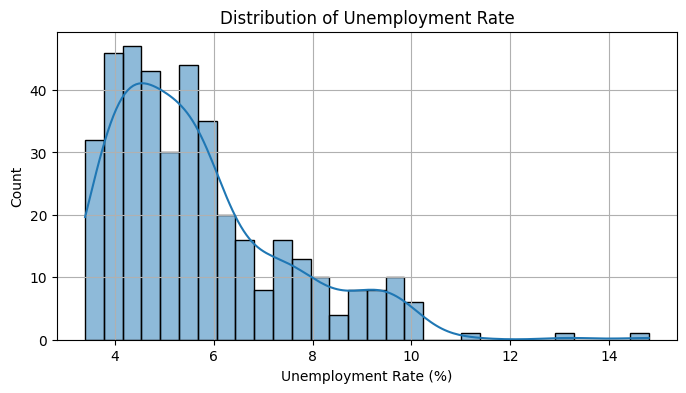

In [36]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Unemployment Rate'], kde=True, bins=30)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

Boxplot (to detect outliers)

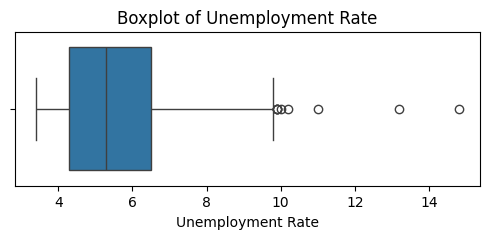

In [37]:
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['Unemployment Rate'])
plt.title("Boxplot of Unemployment Rate")
plt.show()

SEASONAL DECOMPOSITION

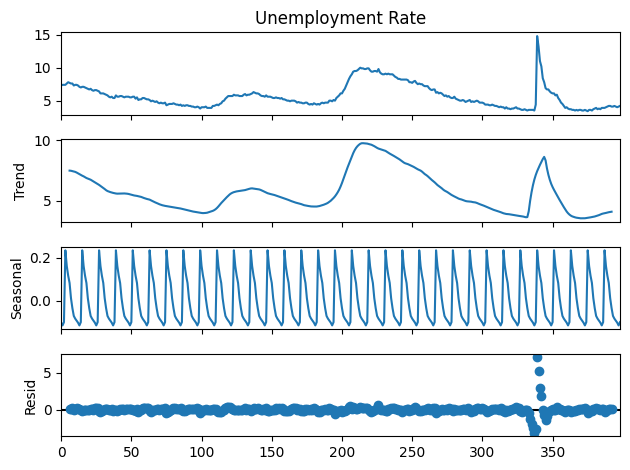

In [40]:
result = seasonal_decompose(df['Unemployment Rate'], model='additive', period=12)
result.plot()
plt.show()

AUTOCORRELATION ANALYSIS

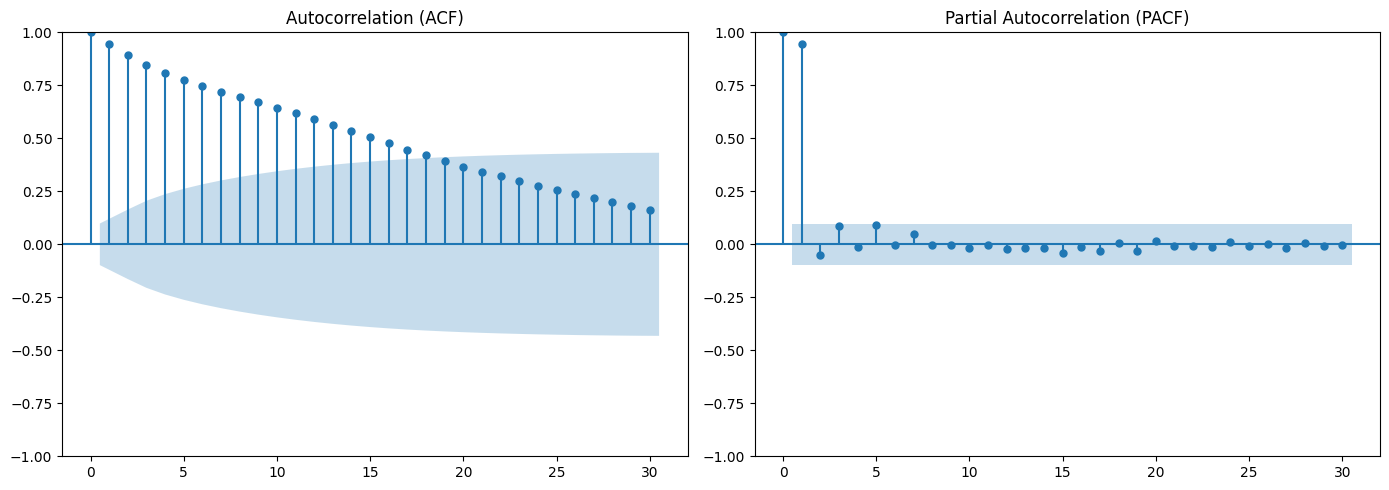

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df['Unemployment Rate'], lags=30, ax=axes[0])
plot_pacf(df['Unemployment Rate'], lags=30, ax=axes[1])
axes[0].set_title('Autocorrelation (ACF)')
axes[1].set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()

CORRELATION MATRIX

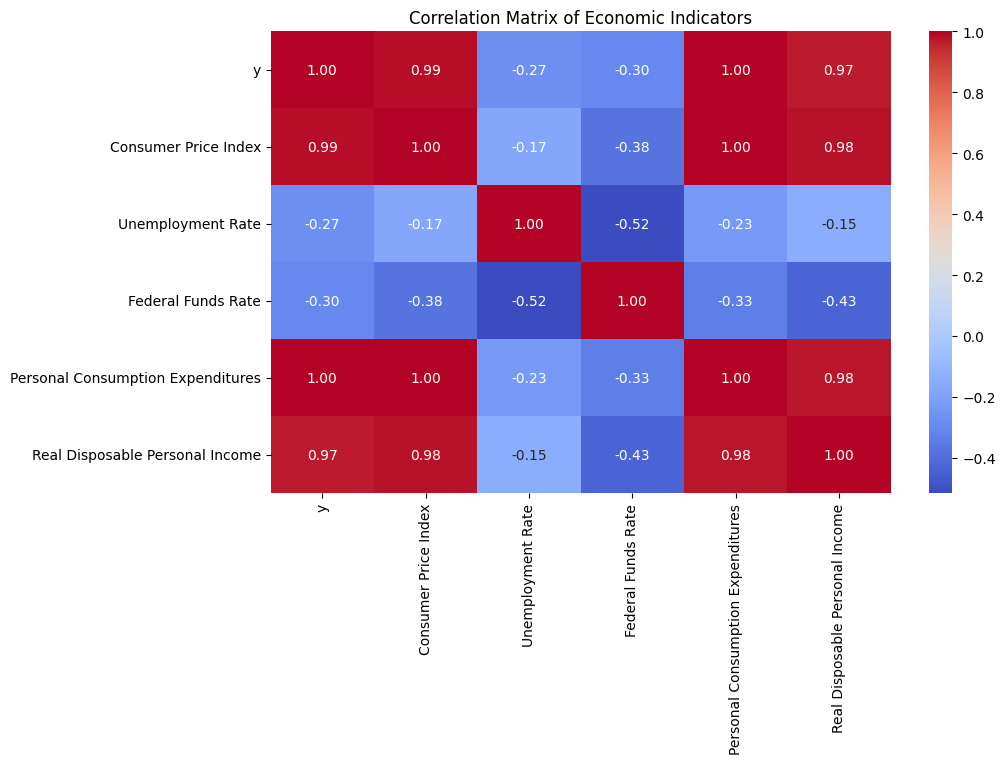

In [43]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=['ds']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Economic Indicators")
plt.show()

ROLLING MEAN (SMOOTH TREND)

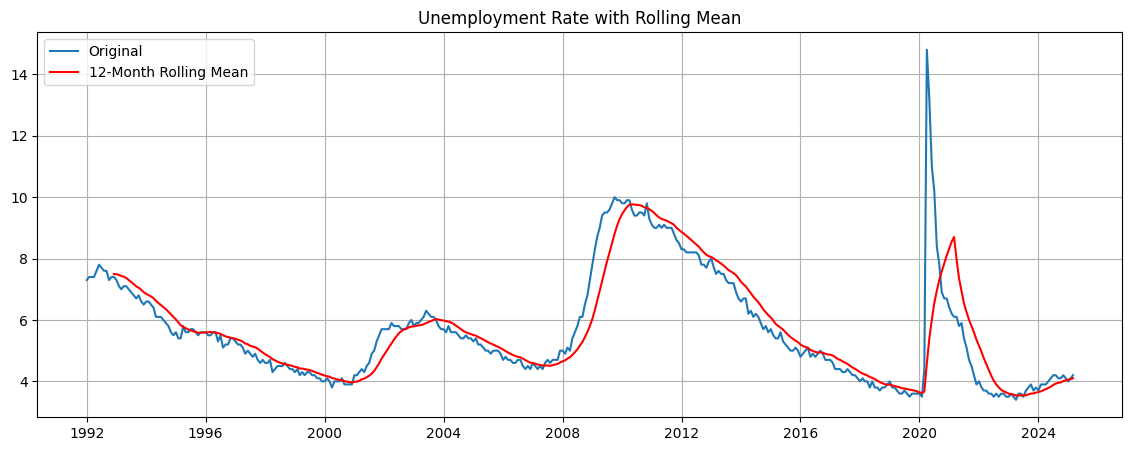

In [44]:
df['rolling_mean'] = df['Unemployment Rate'].rolling(window=12).mean()
plt.figure(figsize=(14, 5))
plt.plot(df['ds'], df['Unemployment Rate'], label='Original')
plt.plot(df['ds'], df['rolling_mean'], label='12-Month Rolling Mean', color='red')
plt.title("Unemployment Rate with Rolling Mean")
plt.legend()
plt.grid(True)
plt.show()

FIRST DIFFERENCE (STATIONARITY CHECK)

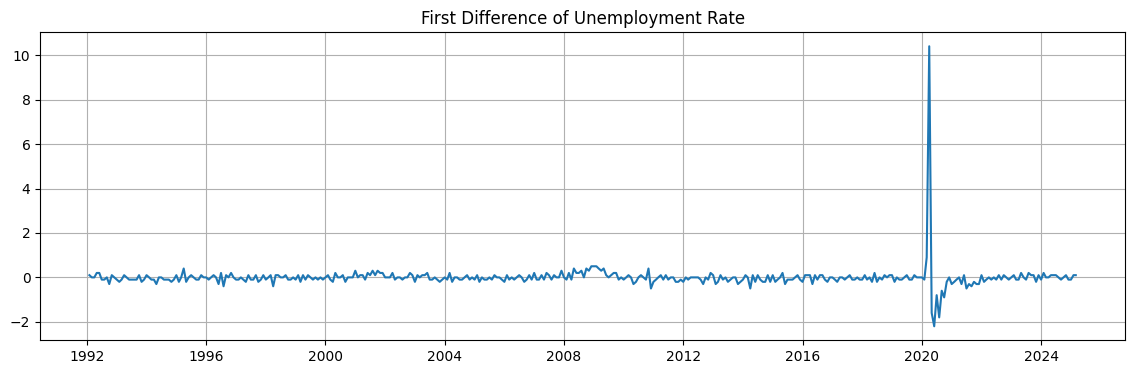

In [45]:
df['unrate_diff'] = df['Unemployment Rate'].diff()
plt.figure(figsize=(14, 4))
plt.plot(df['ds'], df['unrate_diff'], label='Change in Unemployment Rate')
plt.title("First Difference of Unemployment Rate")
plt.grid(True)
plt.show()

SEASONALITY HEATMAP

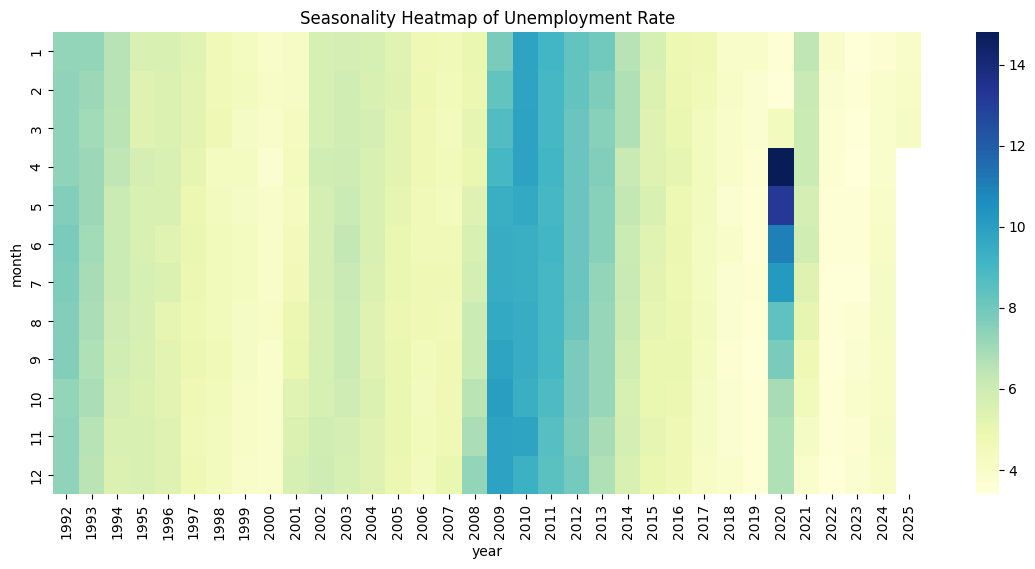

In [46]:
df['year'] = df['ds'].dt.year
df['month'] = df['ds'].dt.month
pivot = df.pivot_table(index='month', columns='year', values='Unemployment Rate')
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title("Seasonality Heatmap of Unemployment Rate")
plt.show()

# Preprocessing

In [51]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

avoiding mutation

In [47]:
df_prep = df.copy()

Set datetime index

In [48]:
df_prep['ds'] = pd.to_datetime(df_prep['ds'])
df_prep.set_index('ds', inplace=True)

Check & fill missing values

In [49]:
df_prep = df_prep.asfreq('MS')
df_prep.interpolate(method='linear', inplace=True)

Feature engineering: Lag and diff (to stationarize)

In [50]:
df_diff = df_prep.diff().dropna()

Scale data

In [52]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_diff)
df_scaled = pd.DataFrame(scaled_values, index=df_diff.index, columns=df_diff.columns)

Create supervised learning format (for ML/LSTM)

In [53]:
def create_supervised(df, n_lags=12):
    df_supervised = pd.DataFrame()
    for i in range(n_lags, 0, -1):
        df_lagged = df.shift(i)
        df_lagged.columns = [f'{col}_lag{i}' for col in df.columns]
        df_supervised = pd.concat([df_supervised, df_lagged], axis=1)
    df_supervised = pd.concat([df_supervised, df], axis=1)
    df_supervised.dropna(inplace=True)
    return df_supervised

df_supervised = create_supervised(df_scaled, n_lags=12)

Train-test split (chronological) to prevent leakage

In [54]:
split_ratio = 0.8
split_index = int(len(df_supervised) * split_ratio)

train = df_supervised.iloc[:split_index]
test = df_supervised.iloc[split_index:]

X_train = train.drop(columns=['y'])
y_train = train['y']
X_test = test.drop(columns=['y'])
y_test = test['y']

# Bayesian Structural Time Series (BSTS)

In [87]:
!pip install orbit-ml --upgrade

In [24]:
from orbit.models import DLT
from orbit.diagnostics.plot import plot_predicted_data
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

2025-05-03 14:11:22 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 250 and samples(per chain): 500.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 250 and samples(per chain): 500.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

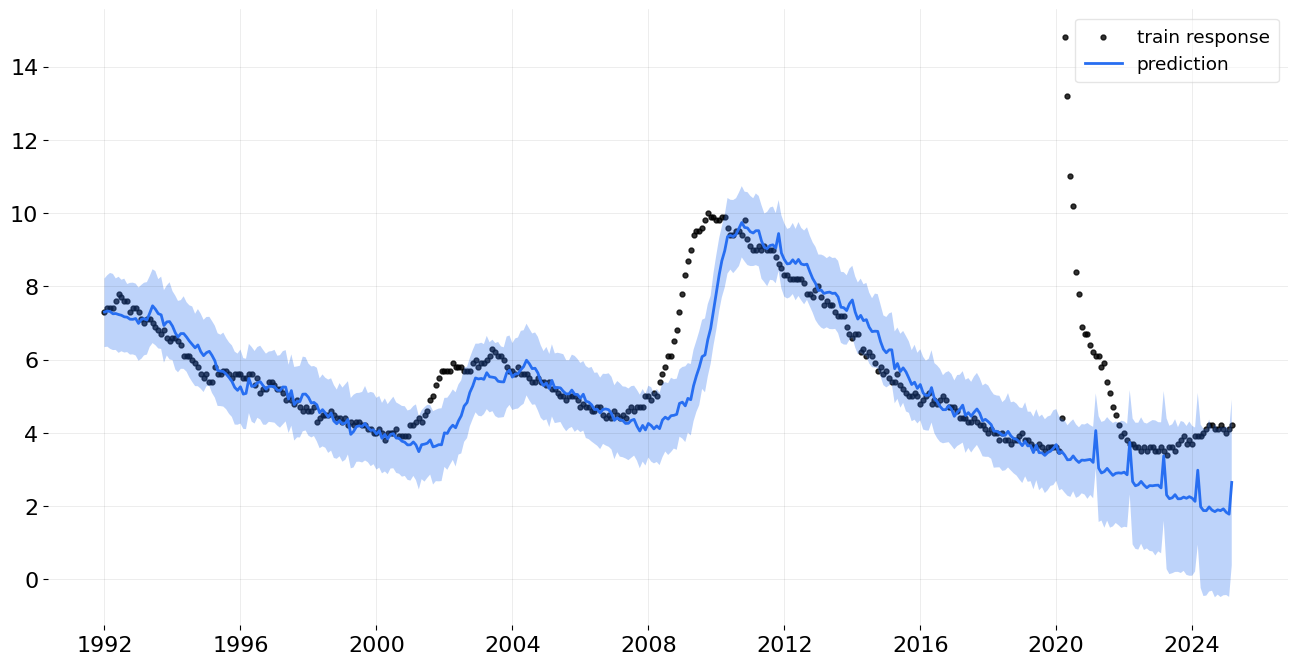

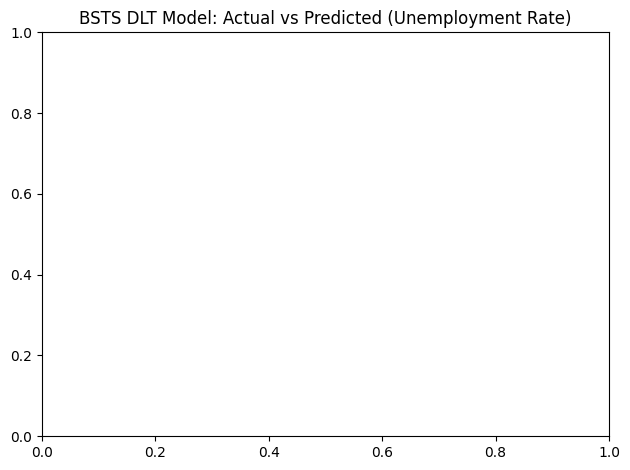

In [59]:
plt.rcParams['font.family'] = 'DejaVu Sans'

df_bsts_uni = df.reset_index()[['ds', 'Unemployment Rate']].rename(columns={'Unemployment Rate': 'y'})

train_df_uni = df_bsts_uni[:-60]
full_df_uni = df_bsts_uni

model_uni = DLT(
    response_col='y',
    date_col='ds',
    seasonality=12,
    seed=2025,
    estimator='stan-mcmc',
    num_warmup=1000,
    num_sample=2000,
    slope_sm_input=0.01,
    level_sm_input=0.01
)

model_uni.fit(train_df_uni)
pred_uni = model_uni.predict(full_df_uni)

plot_predicted_data(full_df_uni, pred_uni, date_col='ds', actual_col='y')
plt.title("BSTS DLT Model: Actual vs Predicted (Unemployment Rate)")
plt.tight_layout()
plt.show()

Univariate BSTS Evaluation

In [60]:
y_true_uni = df[df.columns[df.columns.str.contains('Unemployment Rate')]].values.flatten()
y_pred_uni = pred_uni['prediction'].values

mae_uni = mean_absolute_error(y_true_uni, y_pred_uni)
mse_uni = mean_squared_error(y_true_uni, y_pred_uni)
rmse_uni = np.sqrt(mse_uni)
r2_uni = r2_score(y_true_uni, y_pred_uni)

print("📊 Univariate BSTS Evaluation:")
print(f"MAE:  {mae_uni:.4f}")
print(f"MSE:  {mse_uni:.4f}")
print(f"RMSE: {rmse_uni:.4f}")
print(f"R²:   {r2_uni:.4f}\n")

📊 Univariate BSTS Evaluation:
MAE:  0.7827
MSE:  2.1227
RMSE: 1.4569
R²:   0.3333



# Multivariate BSTS Model with Regressors for modification

2025-05-03 14:13:43 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 250 and samples(per chain): 500.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 250 and samples(per chain): 500.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

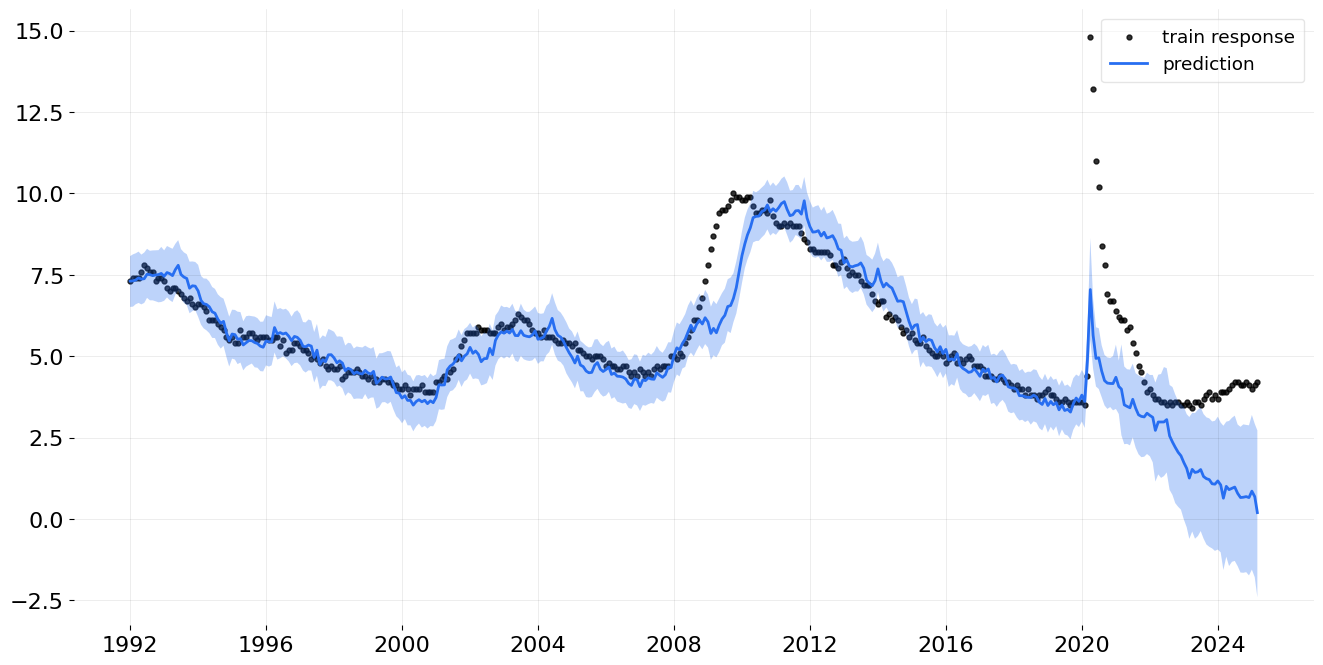

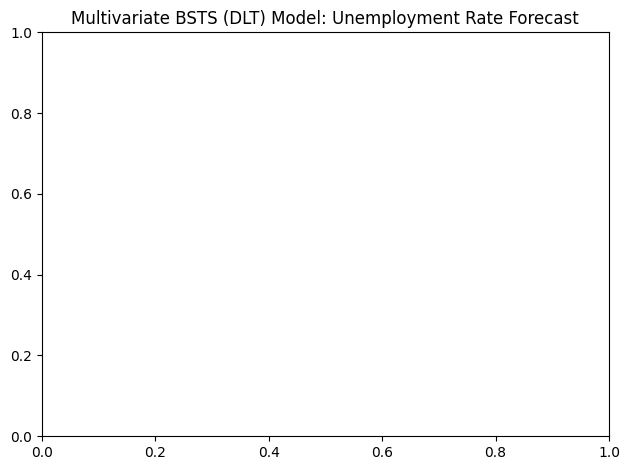

In [61]:
plt.rcParams['font.family'] = 'DejaVu Sans'

regressors = [
    'Consumer Price Index',
    'Federal Funds Rate',
    'Personal Consumption Expenditures',
    'Real Disposable Personal Income'
]

df_bsts_multi = df.reset_index()[['ds', 'Unemployment Rate'] + regressors].rename(columns={
    'Unemployment Rate': 'y'
})

df_bsts_multi[regressors] = df_bsts_multi[regressors].interpolate(method='linear')

train_df_multi = df_bsts_multi[:-60]
full_df_multi = df_bsts_multi

model_multi = DLT(
    response_col='y',
    date_col='ds',
    regressor_col=regressors,
    seasonality=12,
    seed=2025,
    estimator='stan-mcmc',
    num_warmup=1000,
    num_sample=2000,
    slope_sm_input=0.01,
    level_sm_input=0.01
)

model_multi.fit(train_df_multi)
pred_multi = model_multi.predict(full_df_multi)

plot_predicted_data(full_df_multi, pred_multi, date_col='ds', actual_col='y')
plt.title("Multivariate BSTS (DLT) Model: Unemployment Rate Forecast")
plt.tight_layout()
plt.show()

Multivariate BSTS Evaluation

In [62]:
y_true_multi = df[df.columns[df.columns.str.contains('Unemployment Rate')]].values.flatten()
y_pred_multi = pred_multi['prediction'].values

mae_multi = mean_absolute_error(y_true_multi, y_pred_multi)
mse_multi = mean_squared_error(y_true_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_true_multi, y_pred_multi)

print("📊 Multivariate BSTS Evaluation:")
print(f"MAE:  {mae_multi:.4f}")
print(f"MSE:  {mse_multi:.4f}")
print(f"RMSE: {rmse_multi:.4f}")
print(f"R²:   {r2_multi:.4f}")

📊 Multivariate BSTS Evaluation:
MAE:  0.7222
MSE:  1.6730
RMSE: 1.2935
R²:   0.4745


Plot to Compare Actual vs Predicted for Both Models

<ipython-input-63-86794db7469b>:10: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.



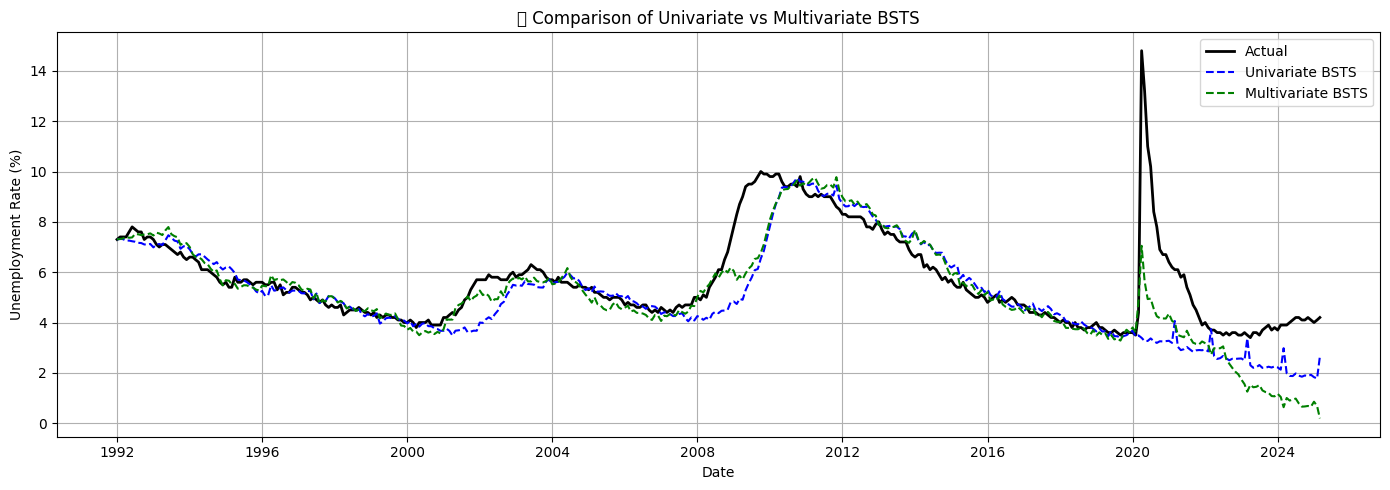

In [63]:
plt.figure(figsize=(14, 5))
plt.plot(df['ds'], y_true_uni, label='Actual', color='black', linewidth=2)
plt.plot(df['ds'], y_pred_uni, label='Univariate BSTS', linestyle='--', color='blue')
plt.plot(df['ds'], y_pred_multi, label='Multivariate BSTS', linestyle='--', color='green')
plt.title("📈 Comparison of Univariate vs Multivariate BSTS")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Bar Plot to Compare Evaluation Metrics

<ipython-input-64-3ecd0d64b89b>:15: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



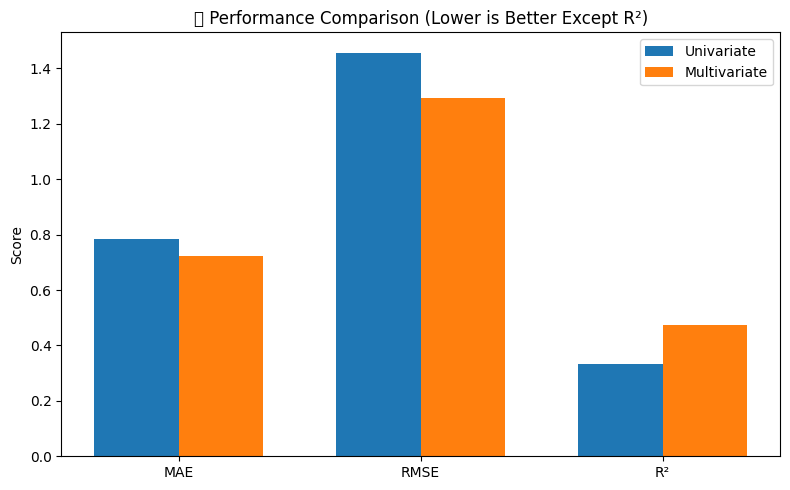

In [64]:
labels = ['MAE', 'RMSE', 'R²']
x = np.arange(len(labels))

uni_vals = [mae_uni, rmse_uni, r2_uni]
multi_vals = [mae_multi, rmse_multi, r2_multi]

bar_width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - bar_width/2, uni_vals, bar_width, label='Univariate')
plt.bar(x + bar_width/2, multi_vals, bar_width, label='Multivariate')
plt.xticks(x, labels)
plt.title("📊 Performance Comparison (Lower is Better Except R²)")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# Interpretability and Explainability

In [69]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9f704836ac344e94dcf09c0db0b2ed273b92af0aedb8b9377b21723bba543556
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [79]:
import shap
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd
from datetime import timedelta
from orbit.diagnostics.plot import plot_predicted_components

PDP: Partial Dependence Plots (Explainability)

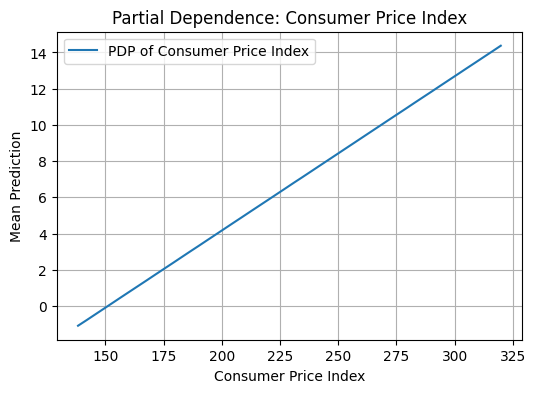

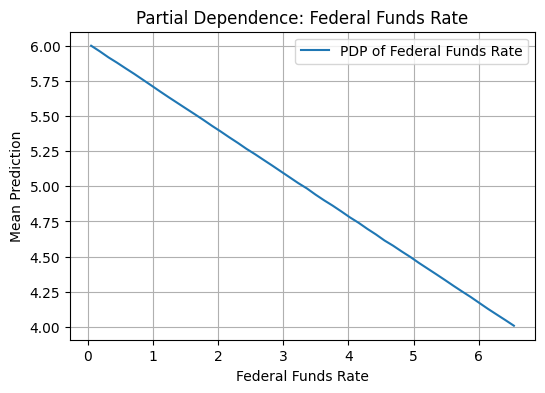

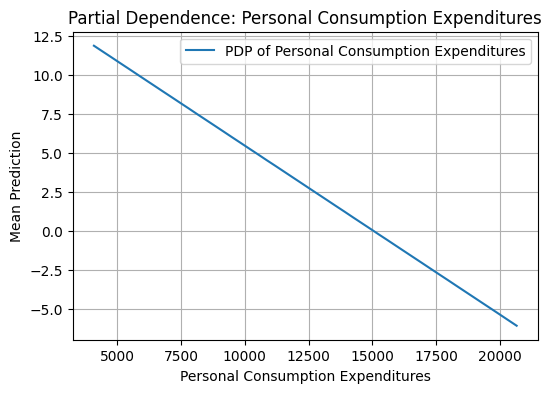

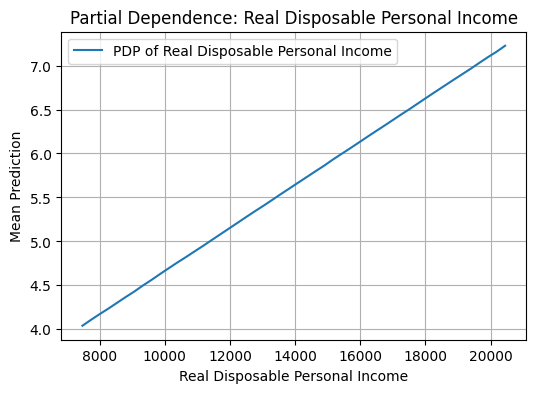

In [66]:
def plot_pdp(model, df, feature, baseline_df, num_points=50):
    x_vals = np.linspace(df[feature].min(), df[feature].max(), num_points)
    preds = []

    for val in x_vals:
        temp_df = baseline_df.copy()
        temp_df[feature] = val
        pred = model.predict(temp_df)['prediction']
        preds.append(np.mean(pred))

    plt.figure(figsize=(6, 4))
    plt.plot(x_vals, preds, label=f'PDP of {feature}')
    plt.xlabel(feature)
    plt.ylabel("Mean Prediction")
    plt.title(f"Partial Dependence: {feature}")
    plt.grid(True)
    plt.legend()
    plt.show()

baseline_df = full_df_multi.copy()
for reg in regressors:
    plot_pdp(model_multi, full_df_multi, reg, baseline_df)


LIME (Explainability)

In [86]:
X = full_df_multi[regressors].values
y = full_df_multi['y'].values

def predict_fn(input_array):
    input_df = pd.DataFrame(input_array, columns=regressors)

    base_date = full_df_multi['ds'].iloc[-1]
    input_df['ds'] = [base_date + timedelta(days=i) for i in range(len(input_df))]

    input_df['y'] = full_df_multi['y'].mean()
    input_df = input_df[['ds', 'y'] + regressors]

    preds = model_multi.predict(input_df)

    pred_array = preds['prediction']
    if isinstance(pred_array, pd.DataFrame):
        return pred_array.mean(axis=1).values
    else:
        return pred_array.values


explainer = LimeTabularExplainer(
    training_data=X,
    mode='regression',
    feature_names=regressors,
    verbose=True
)

i = 100
exp = explainer.explain_instance(X[i], predict_fn)

exp.show_in_notebook()


Intercept -56.01482690952873
Prediction_local [-60.51414964]
Right: 1.9477040758337738


SHAP (only feasible for linear regression-style approximation) (Explainability)

<ipython-input-68-707873db43e0>:11: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



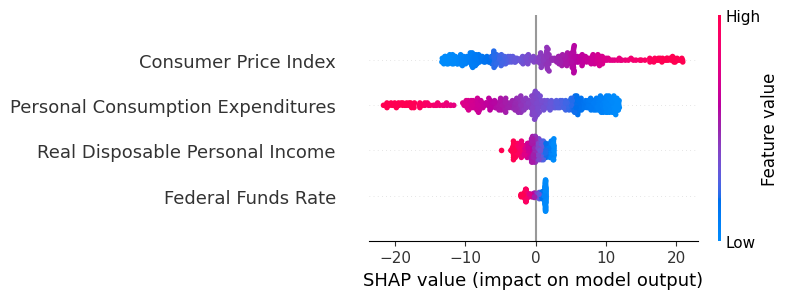

In [68]:
X = full_df_multi[regressors]
y = pred_multi['prediction']
lin_model = LinearRegression().fit(X, y)

explainer = shap.Explainer(lin_model, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X, feature_names=regressors)


Sensitivity Analysis (Explainability)

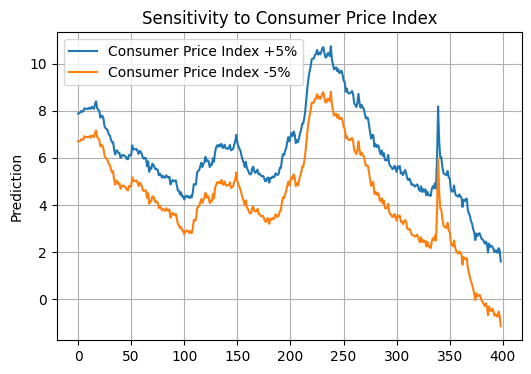

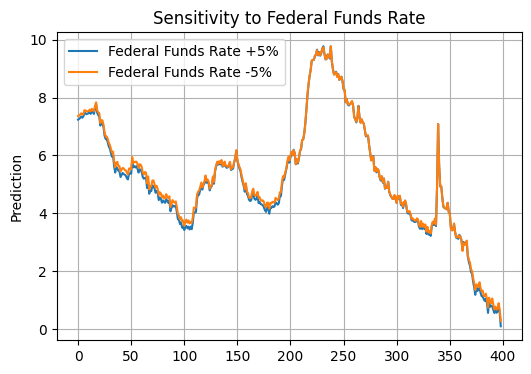

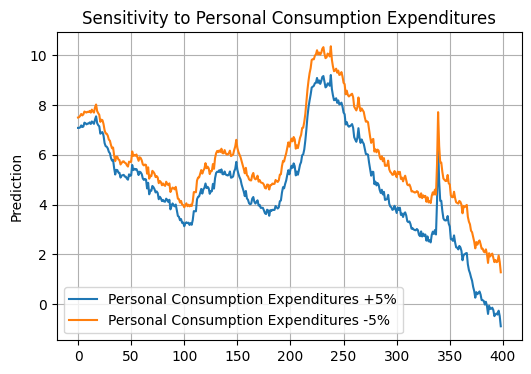

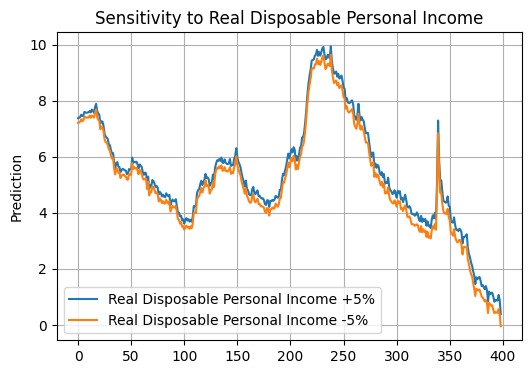

In [71]:
def sensitivity_analysis(model, df, feature, percent_change=0.05):
    df_up = df.copy()
    df_down = df.copy()
    df_up[feature] *= (1 + percent_change)
    df_down[feature] *= (1 - percent_change)

    pred_up = model.predict(df_up)['prediction']
    pred_down = model.predict(df_down)['prediction']

    plt.figure(figsize=(6, 4))
    plt.plot(pred_up, label=f'{feature} +{percent_change*100:.0f}%')
    plt.plot(pred_down, label=f'{feature} -{percent_change*100:.0f}%')
    plt.title(f"Sensitivity to {feature}")
    plt.ylabel("Prediction")
    plt.legend()
    plt.grid(True)
    plt.show()

for reg in regressors:
    sensitivity_analysis(model_multi, full_df_multi, reg)

Orbit Feature Importance (Explainability)


📌 Feature Importance from Orbit (Posterior Coefficients):
                           regressor  coefficient  coefficient_lower  \
1                 Federal Funds Rate    -0.307285          -0.343194   
0               Consumer Price Index     0.085147           0.058677   
2  Personal Consumption Expenditures    -0.001082          -0.001491   
3    Real Disposable Personal Income     0.000245          -0.000034   

   coefficient_upper  importance  
1          -0.271718    0.307285  
0           0.110426    0.085147  
2          -0.000686    0.001082  
3           0.000519    0.000245  


<ipython-input-78-a34853a8699b>:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




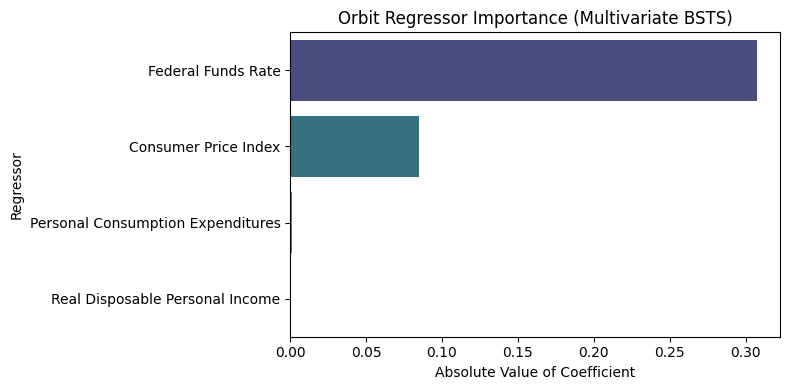

In [78]:
coef_summary['importance'] = coef_summary['coefficient'].abs()
coef_summary_sorted = coef_summary.sort_values(by='importance', ascending=False)

print("\n📌 Feature Importance from Orbit (Posterior Coefficients):")
print(coef_summary_sorted[['regressor', 'coefficient', 'coefficient_lower',
                           'coefficient_upper', 'importance']])

plt.figure(figsize=(8, 4))
sns.barplot(data=coef_summary_sorted, x='importance', y='regressor', palette='viridis')
plt.title("Orbit Regressor Importance (Multivariate BSTS)")
plt.xlabel("Absolute Value of Coefficient")
plt.ylabel("Regressor")
plt.tight_layout()
plt.show()
